In previous lessons we have explored the world of supervised learning (i.e. our data samples $x$ come with a label $y$). We also briefly talked about unsupervised learning and generative modelling, for which no labels are given. We will come back to this paradigm later. Now, we will explore a completely different paradigm: reinforcement learning. Here, rather than having a dataset, we consider an agent and an environment interacting over time (see @fig-rl-scheme). The interaction occurs in a loop: at each step, the agent observes the current *state* of the environment, selects an *action*, which is then applied to the environment, changing its state. Aside from the state, the environment also outputs a *reward* that evaluates the immediate outcome of its decision. As we will see in detail below, the goal here is not to fit a function as before, but rather to wisely choose the actions that leadto the highest cumulative reward..


::: {#fig-rl-scheme}
<img src="../../figures/rl_scheme.png" width="60%"/>

Schematic representation of the agent-environment interaction in RL.
:::

# Examples

Before going in the details of the algorithm, it is useful to understand what can be done with RL. 

**Learning to navigate**

The aim of the agent is to reach a certain target state through a simple or complex environment. The state of the agent is simply its position, its actions relate to its motion, and a positive reward is given when reaching the target.

::: {#fig-frozen}
<img src="../../figures/frozen_lake.gif" width="30%"/>

Frozen Lake environment. Credit: [Farama Foundation](https://gymnasium.farama.org/environments/toy_text/frozen_lake/)
:::

**Learning to control**

Here the agent's goal is control the environment to again reach a target state. For instance, the agent may have access to the control of different parts of the environment (its actions). A reward is given when the control is successful, i.e. we reach the target.

::: {#fig-luna}
<img src="../../figures/lunar_lander.gif" width="30%"/>

Lunar Lander environment. Credit: [Farama Foundation](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
:::

**Learning to play**

The same paradigm is easily applicable to games! Indeed, some of the biggest breakthroughs in RL came from its application to the game [Go](https://www.nature.com/articles/nature16961) and later to [chess](https://www.science.org/doi/10.1126/science.aar6404). There is a very cool documentary about these developments in [Youtube](https://www.youtube.com/watch?v=WXuK6gekU1Y).

**Learning to create quantum experiments**

As you may already guess, RL has a lot of applications in Physics. For instance, an agent can learn to place different optical devices (its actions) into a quantum optical table to reach a certain quantum state! 


::: {#fig-quantum}
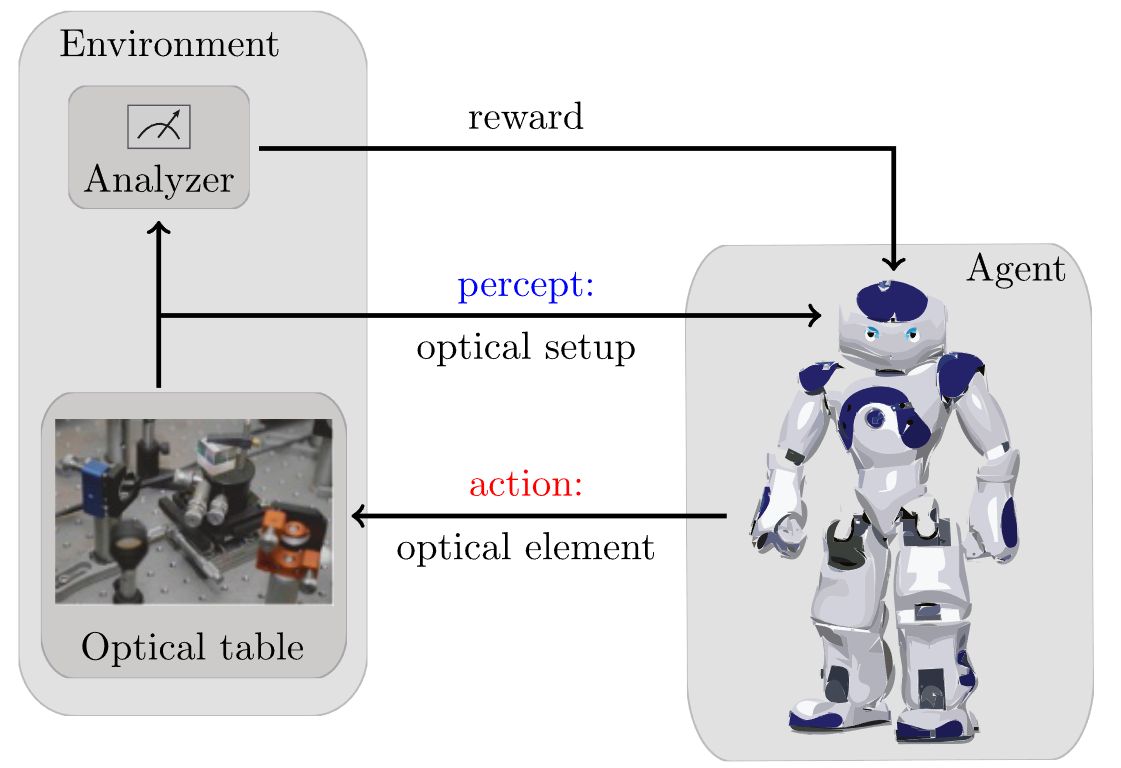

RL agent in an quantum optics experiment. Credit: [QIC.UIBK group](https://www.pnas.org/doi/10.1073/pnas.1714936115)
:::

# Basic elements
All previous problems share almost the same elements. We have already talked about actions and states, and will come back to these a bit later. Aside of these, we identify four main subelements:

- **Policy:** ensemble of rules that set the behaviour of the agent.
- **Reward signal:** defines the goal in a RL problem.
- **Value function:** internal to the agent, specifies what is good on the long run.
- **Model:** optional, aims to mimic the behaviour of the environment.

# Multi-armed bandits

Multi-armed bandits (MAB) is a common toy model in RL. The setup is as follows: we have a $k$-armed bandit, defining our $k$ actions. Each arm has a given probability distribution of reward, typically a normal distribution $R_k=\mathcal{N}(\mu_k, \sigma_k)$. From this probability, we have the expected reward of each arm, hence of each action. We typically refer to this as the *value* of each action, and define the value function 

\begin{equation}
q^*(a) = \mathbb{E}[ R_t | A_t = a],
\end{equation}

where $R_t$ and $A_t$ refer to the reward  recevied and action taken at time $t$. Of course we don't know $q^*(a)$ a priori, but we can estimate it by means of interaction with the bandints (the environment). If we define our estimate as $Q(a)$, our goal is to make $Q(a)\rightarrow q^*(a)$. A simple way of doing that is as follows:

\begin{equation}
Q_t(a) = \frac{\text{sum of rewards received when doing action } a}{\text{number of times we took action } a} = \frac{\sum_{i=1}^{t-1} R_i \delta (A_i -a)}{\sum_{i=1}^{t-1}\delta(A_i-a)}
\end{equation}

From this value function, we can construct our *policy*, by for instance taking $A_t = \text{argmax}_a Q_t(a)$. Rather than calculating this equation at each time step, we can rather update it incrementally as follows:
\begin{equation}
Q_{t+1}(a) = Q_t(a) + \frac{1}{t} (R_t(a) - Q_t(a)).
\end{equation}

## Exploitation vs. exploration
The policy above "exploits" the learned knowledge. However, this may be counterproductive because the agent's knowledge of the action values is not perfect. If the agent happens to find a good, but not optimal, action early on, a purely greedy policy will stick to it forever, never discovering the truly best action. To avoid this, the agent must also explore. It must sometimes try actions that it does not believe are the best. This allows it to improve its estimates of the values of all actions and increases the chances of finding the optimal one. This is the fundamental exploration-exploitation dilemma in reinforcement learning: the agent must balance exploiting its current knowledge to get high rewards with exploring to gain new knowledge that could lead to even higher rewards in the future. 

To account for this, we consider the $\epsilon$-greedy policy, which consists in taking the action $A_t = \text{argmax}_a Q_t(a)$ with probability $1-\epsilon$, and a random action with probability $\epsilon$. This simple modification allows the agent to explore the environment, while still exploiting its knowledge most of the time. More formally,

\begin{equation}
\pi(a|t) = \begin{cases} 1-\epsilon + \frac{\epsilon}{k} & \text{if } a = \text{argmax}_a Q_t(a) \\[6pt] \frac{\epsilon}{k} & \text{otherwise} \end{cases}
\end{equation}

::: {.callout-tip}
## Exercise

Let's put the previous in practice! Here is a function implementing a multi-armed bandit environment. Complete the code to create an agent that uses the $\epsilon$-greedy policy to interact with the environment and learn the value function $Q(a)$ for each action. Train your agent over $2000$ episodes with three different epsilon values: [0, 0.01, 0.1]. Plot a time average of the reward over time for each epsilon value to see how exploration affects learning.

**Bonus:** Get the optimal action from the environment (the one with higher `mean_r`) and plot the percentage of times the agent selects this action over time for each epsilon value.

In [24]:
import numpy as np

class MAB:
  ''' Creates a multiarmed bandit where each bandit outputs a reward coming 
  from a Gaussian distribution. '''
  
  def __init__(self, num_b):
    
    self.N = num_b # Number of bandits
    self.mean_r = np.random.normal(0, 1, self.N) # Reward probability of each bandit
    
          
  def get_reward(self, action):
    # Given action, outputs a reward based on the probability of success of bandit
    if action > self.N-1:
      print('Bandit number'+str(action)+' does not exists!')
      return 0
    else: 
      reward = np.random.normal(self.mean_r[action],1)
      return reward

    
# To create the environment use:
number_bandits = 10
mab_environment = MAB(num_b = number_bandits)

# To do an action over the environment and get the reward use:
action = 1 # As we have 10 bandits, action must be a number between 0 and 9
reward = mab_environment.get_reward(action)

:::

In [25]:
#| code-fold: true
#| code-summary: Solution - Agent

class egreedy_agent:

    def __init__(self, num_actions, epsilon):
        self.num_actions = num_actions
        self.epsilon = epsilon
        self.Q = np.zeros(num_actions)  # Initialize value function
        self.action_counts = np.zeros(num_actions)  # Count of actions taken

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.num_actions)  # Explore
        else:
            return np.argmax(self.Q)  # Exploit
            
    def update_value(self, action, reward):
        self.action_counts[action] += 1
        n = self.action_counts[action]
        self.Q[action] += (1 / n) * (reward - self.Q[action])  # Update value function

In [ ]:
#| code-fold: true
#| code-summary: Solution - Training

from tqdm import tqdm

num_runs = 2000
epochs = 2000
epsilons = [0, 0.01, 0.1]

rews = np.zeros((len(epsilons), num_runs, epochs))
opt_as= np.zeros((len(epsilons), num_runs, epochs))

for idxe, eps in enumerate(epsilons):
    for idxr in tqdm(range(num_runs)):
        agent = egreedy_agent(num_actions=number_bandits, epsilon=eps)
        mab_environment = MAB(num_b = number_bandits)
        opt_action = np.argmax(mab_environment.mean_r)
        for t in range(epochs):
            action = agent.select_action()
            reward = mab_environment.get_reward(action)
            agent.update_value(action, reward)
            rews[idxe, idxr, t] = reward
            opt_as[idxe, idxr, t] = action == opt_action

Text(0.5, 0, 'Episodes')

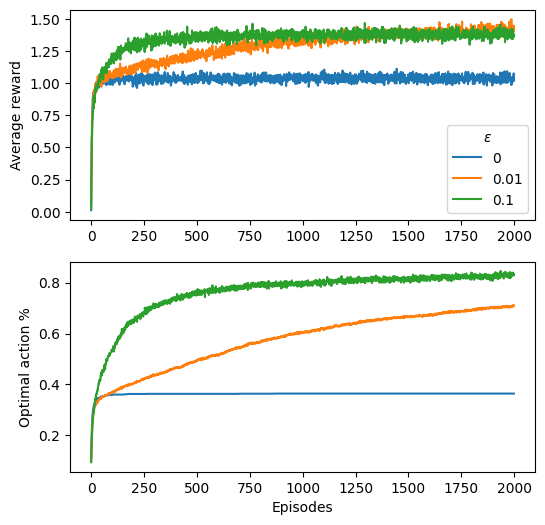

In [31]:
#| code-fold: true
#| code-summary: Solution - Figure

import matplotlib.pyplot as plt
fig, ax = plt.subplots(2,1, figsize=(6,6))

for rew, eps in zip(rews, epsilons):
    ax[0].plot(rew.mean(0), label = eps)
ax[0].legend(title = r'$\epsilon$')
for act in opt_as:
    ax[1].plot(act.mean(0))

ax[0].set_ylabel('Average reward')
ax[1].set_ylabel('Optimal action %')
ax[1].set_xlabel('Episodes')


## Non-stationary problems
We often want to consider non-stationary problems, where the value of each action may change over time. In this case, we can use a constant step-size parameter $\alpha$ to update our value function:
\begin{equation}
Q_{t+1}(a) = Q_t(a) + \alpha (R_t(a) - Q_t(a)),
\end{equation}
where the factor $\alpha$ determines how fast we want to adapt to changes in the environment: if $\alpha$ is small, updates are conservative and rely heavily on past estimates. On the other hand, if $\alpha$ is large (close to 1), the estimate rapidly adapts to the most recent reward.


::: {.callout-tip}
## Exercise

Let's do the same as bove but now with a MAB that changes its reward function every a certain amount of function calls. Do the exploration with a fixed $\epsilon$ (for instance the best one from the previous exercise), but now tuning the $\alpha$, from $10^{-2}$ to $1$.

In [2]:
import numpy as np

class MAB_nonstationary:
    ''' Creates a multiarmed bandit where each bandit outputs a reward coming 
    from a Gaussian distribution. '''
    
    def __init__(self, num_b, steps_reset = 500):
    
        self.N = num_b # Number of bandits
        self.reset_reward()
        self.steps_reset = steps_reset

    def reset_reward(self):
        self.func_call = 0
        self.mean_r = np.random.normal(0, 1, self.N) # Reward probability of each bandit
    
          
    def get_reward(self, action):
    
    
        self.func_call += 1
        if self.func_call == self.steps_reset:
            self.reset_reward()
        
          
        # Given action, outputs a reward based on the probability of success of bandit
        if action > self.N-1:
          print('Bandit number'+str(action)+' does not exists!')
          return 0
        else: 
          reward = np.random.normal(self.mean_r[action],1)
          return reward

    
# To create the environment use:
number_bandits = 10
mab_environment = MAB_nonstationary(num_b = number_bandits)

# To do an action over the environment and get the reward use:
action = 1 # As we have 10 bandits, action must be a number between 0 and 9
reward = mab_environment.get_reward(action)

:::

In [17]:
#| code-fold: true
#| code-summary: Solution - Agent

class egreedy_agent_nonstationary:

    def __init__(self, num_actions, epsilon, alpha):
        self.num_actions = num_actions
        self.epsilon = epsilon
        self.Q = np.zeros(num_actions)  # Initialize value function
        self.action_counts = np.zeros(num_actions)  # Count of actions taken
        self.alpha = alpha

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.num_actions)  # Explore
        else:
            return np.argmax(self.Q)  # Exploit
            
    def update_value(self, action, reward):
        self.action_counts[action] += 1
        n = self.action_counts[action]
        self.Q[action] += self.alpha* (reward - self.Q[action])  # Update value function

In [ ]:
#| code-fold: true
#| code-summary: Solution - Training

from tqdm.auto import tqdm

num_runs = 2000
epochs = 2000
alphas = [False, 1e-2, 1e-1, 1]

rews = np.zeros((len(alphas), num_runs, epochs))
opt_as= np.zeros((len(alphas), num_runs, epochs))

for idxe, alp in enumerate(alphas):    
    for idxr in tqdm(range(num_runs)):

        if not alphas:
            agent = egreedy_agent(num_actions=number_bandits, epsilon=0.1)
        else:
            agent = egreedy_agent_nonstationary(num_actions=number_bandits, epsilon= 0.1, alpha = alp)
        mab_environment = MAB_nonstationary(num_b = number_bandits)
        
        for t in range(epochs):
            action = agent.select_action()
            reward = mab_environment.get_reward(action)
            agent.update_value(action, reward)
            rews[idxe, idxr, t] = reward
            opt_as[idxe, idxr, t] = action == np.argmax(mab_environment.mean_r)

Text(0.5, 0, 'Episodes')

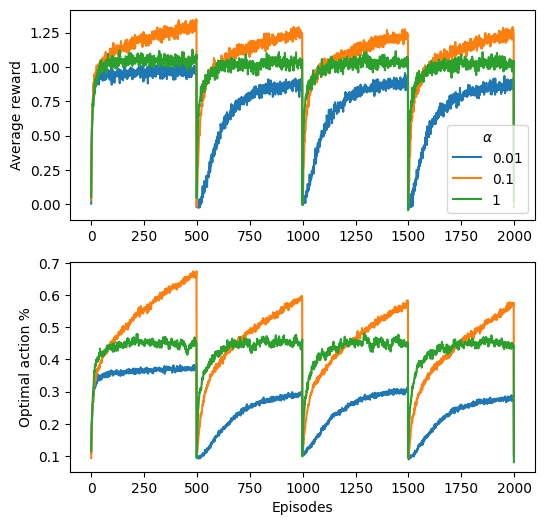

In [20]:
#| code-fold: true
#| code-summary: Solution - Figure

import matplotlib.pyplot as plt
fig, ax = plt.subplots(2,1, figsize=(6,6))

for rew, alpha in zip(rews, alphas):
    ax[0].plot(rew.mean(0), label = alpha if alpha else 'stationary')
ax[0].legend(title = r'$\alpha$')
for act in opt_as:
    ax[1].plot(act.mean(0))

ax[0].set_ylabel('Average reward')
ax[1].set_ylabel('Optimal action %')
ax[1].set_xlabel('Episodes')